In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brent, golden, bracket

In [16]:
def f(x):
    return (
        0.08*(x+3)**2
        - 1.5*np.exp(-(x+2)**2)
        - 5*np.exp(-25*(x-2)**2)
        + 0.1*np.sin(5*x)
    )

In [17]:
xmin, xmax = -6, 5

X = np.linspace(xmin, xmax, 1000)
Y = f(X)

f_star = Y.min()

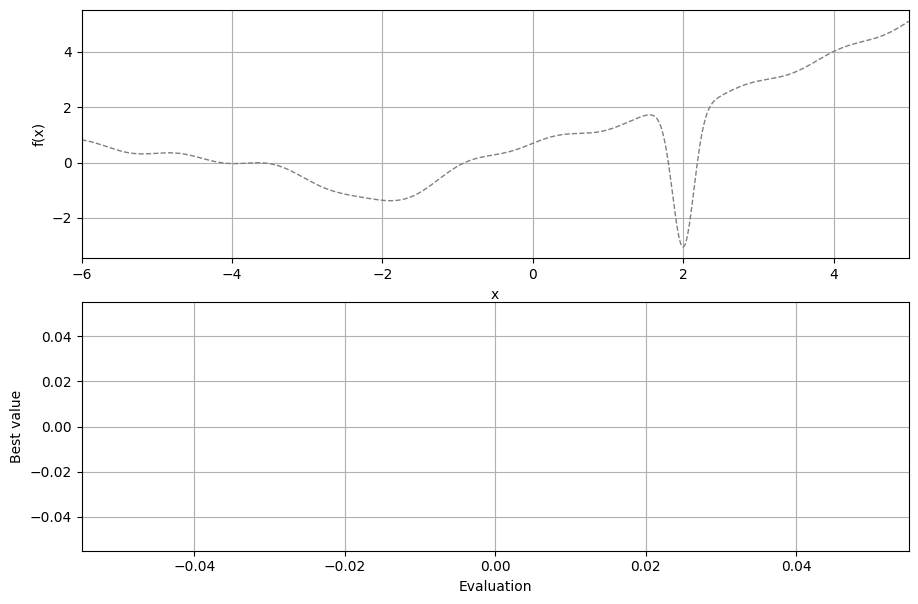

In [18]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9,6),
    gridspec_kw={"height_ratios":[1,1]}
)

plt.tight_layout()

ax1.plot(X, Y, lw=1, ls='dashed', c='grey', label='True function')

ax1.set_xlim(xmin, xmax)
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.grid(True)

ax2.set_xlabel("Evaluation")
ax2.set_ylabel("Best value")
ax2.grid(True)

eval_scatter, = ax1.plot([], [], 'ko', ms=6)

best_scatter, = ax1.plot([], [], 'ro', ms=10)

best_line, = ax2.plot([], [], lw=2)

history_x = []
history_y = []

best_history = []

annotations = []

n_points = 20
x_eval = np.linspace(xmin, xmax, n_points)

def update(frame):

    x = x_eval[frame]
    y = f(x)

    history_x.append(x)
    history_y.append(y)

    # running minimum
    idx = np.argmin(history_y)

    best_history.append(history_y[idx])

    # remove old labels
    for ann in annotations:
        ann.remove()

    annotations.clear()

    # update evaluated points
    eval_scatter.set_data(history_x, history_y)

    # highlight best point
    best_scatter.set_data(
        [history_x[idx]],
        [history_y[idx]]
    )

    # annotate every evaluation
    for i, (xx, yy) in enumerate(zip(history_x, history_y)):
        annotations.append(
            ax1.annotate(
                str(i),
                (xx, yy),
                xytext=(3,5),
                textcoords="offset points",
                fontsize=8
            )
        )

    # convergence plot
    best_line.set_data(
        np.arange(len(best_history)),
        best_history
    )

    ax2.relim()
    ax2.autoscale_view()

    return eval_scatter, best_scatter, best_line

In [19]:
from matplotlib.animation import FuncAnimation

ani = FuncAnimation(
    fig,
    update,
    frames=n_points,
    interval=500,
    repeat=False
)

ani.save('test.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.


In [20]:
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


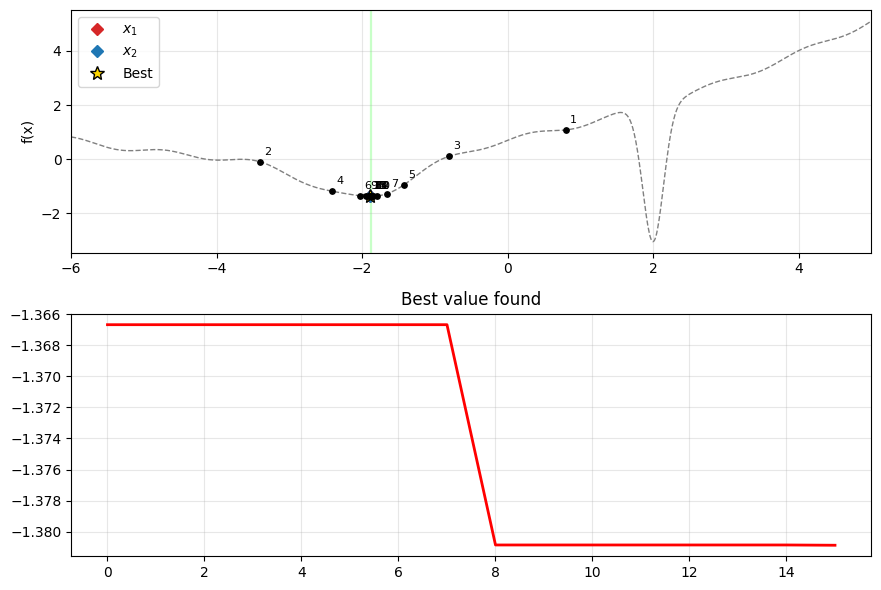

In [24]:
# ============================================================
# Golden Search generator
# ============================================================

def golden_search(f, a, b, tol=1e-3):

    tau = (np.sqrt(5)-1)/2

    x1 = b - tau*(b-a)
    x2 = a + tau*(b-a)

    f1 = f(x1)
    f2 = f(x2)

    history = [
        (0, x1, f1),
        (1, x2, f2)
    ]

    counter = 2

    while abs(b-a) > tol:

        best = min(history, key=lambda h: h[2])

        yield {
            "a":a,
            "b":b,
            "x1":x1,
            "x2":x2,
            "f1":f1,
            "f2":f2,
            "history":history.copy(),
            "best":best
        }

        if f1 < f2:

            b = x2
            x2 = x1
            f2 = f1

            x1 = b - tau*(b-a)
            f1 = f(x1)

            history.append((counter, x1, f1))

        else:

            a = x1
            x1 = x2
            f1 = f2

            x2 = a + tau*(b-a)
            f2 = f(x2)

            history.append((counter, x2, f2))

        counter += 1

# ============================================================
# Create optimizer
# ============================================================

states = list(golden_search(f, xmin, xmax, tol=1.e-2))

# ============================================================
# Figure
# ============================================================

fig = plt.figure(figsize=(9,6))

gs = fig.add_gridspec(2,1,height_ratios=[1,1])

ax = fig.add_subplot(gs[0])
ax_best = fig.add_subplot(gs[1])
# ax_width = fig.add_subplot(gs[2])

ax.plot(X,Y,color='grey',lw=1, ls='dashed')

ax.set_xlim(xmin,xmax)
ax.set_ylabel("f(x)")
ax.grid(alpha=.3)

ax_best.set_title("Best value found")
ax_best.grid(alpha=.3)

# ax_width.set_title("Bracket length")
# ax_width.set_yscale("log")
# ax_width.grid(alpha=.3)

# ============================================================
# Artists
# ============================================================

scatter = ax.scatter([],[],s=15,c='k',zorder=3)

x1_artist, = ax.plot([],[],'D',color='tab:red',ms=6,label="$x_1$")

x2_artist, = ax.plot([],[],'D',color='tab:blue',ms=6,label="$x_2$")

best_artist, = ax.plot([],[],'*',color='gold',ms=10,
                       markeredgecolor='black',
                       label="Best")

ax.legend(loc="upper left")

best_line, = ax_best.plot([],[],'r',lw=2)

# width_line, = ax_width.plot([],[],'g',lw=2)

annotations=[]

best_history=[]
width_history=[]

bracket_patch=None

# ============================================================
# Animation
# ============================================================

def update(frame):

    global bracket_patch

    state = states[frame]

    # ----------------------------------------

    if bracket_patch is not None:
        bracket_patch.remove()

    bracket_patch = ax.axvspan(
        state["a"],
        state["b"],
        color='lime',
        alpha=.15
    )

    # ----------------------------------------

    hist = state["history"]

    xs = [h[1] for h in hist]
    ys = [h[2] for h in hist]

    scatter.set_offsets(np.c_[xs,ys])

    # ----------------------------------------

    for ann in annotations:
        ann.remove()

    annotations.clear()

    for idx,x,y in hist:

        annotations.append(
            ax.annotate(
                str(idx),
                (x,y),
                xytext=(3,5),
                textcoords='offset points',
                fontsize=8
            )
        )

    # ----------------------------------------

    x1_artist.set_data(
        [state["x1"]],
        [state["f1"]]
    )

    x2_artist.set_data(
        [state["x2"]],
        [state["f2"]]
    )

    # ----------------------------------------

    bidx,bx,by = state["best"]

    best_artist.set_data([bx],[by])

    # ----------------------------------------

    best_history.append(by)

    width_history.append(
        state["b"]-state["a"]
    )

    best_line.set_data(
        np.arange(len(best_history)),
        best_history
    )

    # width_line.set_data(
    #     np.arange(len(width_history)),
    #     width_history
    # )

    ax_best.relim()
    ax_best.autoscale_view()

    # ax_width.relim()
    # ax_width.autoscale_view()

    return ()

# ============================================================

ani = FuncAnimation(
    fig,
    update,
    frames=len(states),
    interval=800,
    repeat=False
)
ani.save('golden.gif')
plt.tight_layout()
plt.show()